In [15]:
import pandas as pd
import pickle
import glob
import google_conf
import os
import json
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
import itertools
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.io as pio


In [16]:
# emlap_catalogue = google_conf.setup(sheet_url="https://docs.google.com/spreadsheets/d/1bkHHTYc86K2IuEXqfYfkDNt5LovtvCU3gvqHIbVio88/edit?usp=sharing", service_account_path="../../../ServiceAccountsKey.json")

In [17]:
try:
    emlap_metadata = pd.read_csv("../data/emlap_metadata.csv", sep=";")
except:
    emlap_metadata = pd.read_csv("https://raw.githubusercontent.com/CCS-ZCU/EMLAP_ETL/refs/heads/master/data/emlap_metadata.csv", sep=";")

In [7]:
id_label_dict = {}
for id, index, year in zip(emlap_metadata["No."], emlap_metadata["author_name"].astype(str), emlap_metadata["date_publication"]):
    id_label_dict[id] = index.partition(",")[0] + " " + str(year)
id_label_dict

{100001: 'Augurelli 1515',
 100002: 'Pseudo-Lull 1518',
 100003: 'Panteo 1518',
 100004: 'Panteo 1519',
 100005: 'Panteo 1530',
 100006: 'Savonarola 1532',
 100007: 'nan 1550',
 100008: 'Severinus 1571',
 100009: 'nan 1518',
 100010: 'Bracesco 1548',
 100011: 'nan 1541',
 100012: 'Gessner 1552',
 100013: 'Ulstadt 1525',
 100014: 'Toxites 1567',
 100015: 'Gessner 1569',
 100016: 'Bonus 1546',
 100017: 'Bodenstein 1559',
 100018: 'Trevisanus 1567',
 100019: 'Ulstadt 1526',
 100020: 'Dorn 1569',
 100021: 'Dorn 1567',
 100022: 'nan 1550',
 100023: 'Paracelsus 1553',
 100024: 'Fanianus 1560',
 100025: 'Pseudo-Lull 1563',
 100026: 'Garlandius 1560',
 100027: 'Paracelsus 1568',
 100028: 'Ruscelli 1563',
 100029: 'Paracelsus 1560',
 100030: 'Rupescissa 1561',
 100031: 'Phaedro 1562',
 100032: 'Ventura 1571',
 100033: 'Pseudo-Paracelsus 1582',
 100034: 'Penot 1594',
 100035: 'Dorn 1570',
 100036: 'De Vadis 1595',
 100037: 'Duchesne 1575',
 100038: 'nan 1572',
 100039: 'nan 1572',
 100040: 'Pseu

In [8]:
lemmatized_sents_path = "/srv/data/tome/tome-corpus/lemmatized_sents_v3-0/"

In [9]:
os.listdir(lemmatized_sents_path)

['100032.txt',
 '100006.txt',
 '100069.txt',
 '100048.txt',
 '100029.txt',
 '100020.txt',
 '100059.txt',
 '100040.txt',
 '100030.txt',
 '100023.txt',
 '100031.txt',
 '100063.txt',
 '100010.txt',
 '100050.txt',
 '100047.txt',
 '100014.txt',
 '100052.txt',
 '100028.txt',
 '100021.txt',
 '100001.txt',
 '100026.txt',
 '100015.txt',
 '100008.txt',
 '100024.txt',
 '100035.txt',
 '100002.txt',
 '100012.txt',
 '100070.txt',
 '100037.txt',
 '100046.txt',
 '100068.txt',
 '100044.txt',
 '100038.txt',
 '100066.txt',
 '100025.txt',
 '100056.txt',
 '100057.txt',
 '100022.txt',
 '100013.txt',
 '100062.txt',
 '100042.txt',
 '100003.txt',
 '100019.txt',
 '100061.txt',
 '100071.txt',
 '100065.txt',
 '100074.txt',
 '100009.txt',
 '100007.txt',
 '100045.txt',
 '100058.txt',
 '100060.txt',
 '100017.txt',
 '100067.txt',
 '100043.txt',
 '100034.txt',
 '100039.txt',
 '100036.txt',
 '100055.txt',
 '100033.txt',
 '100049.txt',
 '100011.txt',
 '100072.txt',
 '100054.txt',
 '100004.txt',
 '100075.txt',
 '100016.t

In [10]:
filepath = lemmatized_sents_path + '100075.txt'
with open(filepath, 'r') as f:
    sents_lemmata = f.readlines()
sents_lemmata[90:150]

['corruptio corpus separo spiritus recipio aer chaos superior inferior firmamentum\n',
 'uita compositus elementum aqua fluxio destituo aqua morior\n',
 'uita ignis aer perseipse uiuo res elementatus uita tribuo\n',
 'terra morior elementum inuisibilis occulo uita\n',
 'singulus considero\n',
 'uita herba planta radix liquor terra\n',
 'uita lignum insero resina\n',
 'uita resina terebinthinus gummus carabus muscilaginosa splendeo materia pinguedo\n',
 'uita dulcedinosor sacca mel manna cassia\n',
 'subtilis tingo dulcedo balsamitus uirtus dico\n',
 'uita unio splendor amitto calematio\n',
 'uita corallum gemma color elicio spiritus uinum\n',
 'uita sal spiritus aqua fortis\n',
 'uita sulphur combustibilis foeteo pinguedo\n',
 'uita lapis silex muscilaginosa materia\n',
 'uita marcasita cachimia talcum granatus combletus antimonium metallicus spiritingo\n',
 'uita argentum uiuus calor occulo manifestus frigus pelliceus uestis uideo exemplum\n',
 'uita metallum insero pinguedo terreus r

In [11]:
# Get all .txt files in the lemmatized_sents directory
filenames = []
file_paths = glob.glob(lemmatized_sents_path + '*.txt')
lemmata_all = []
docs_lemmata = []
for file_path in file_paths:
    filename = file_path.rpartition("/")[2]
    id = filename.partition(".")[0]
    doc_lemmata = []
    with open(file_path, 'r') as f:
        lines = f.readlines()
        # Now 'lines' is a list where each element is a line from the file.
        for line in lines:
            # Process each line (each lemmatized sentence) here
            doc_lemmata.extend(line.strip().split())
    if len(doc_lemmata) > 0:
        filenames.append(id)
        docs_lemmata.append(" ".join(doc_lemmata))
    lemmata_all.extend(doc_lemmata)

In [12]:
len(docs_lemmata)

73

In [13]:
len(filenames)

73

In [14]:
nltk.FreqDist(docs_lemmata[0].split()).most_common(50)

[('dico', 724),
 ('facio', 623),
 ('corpus', 606),
 ('argentum', 594),
 ('lapis', 579),
 ('ignis', 568),
 ('aqua', 489),
 ('natura', 461),
 ('aurum', 457),
 ('habeo', 363),
 ('possum', 323),
 ('sulphur', 315),
 ('pono', 300),
 ('terra', 299),
 ('pars', 298),
 ('fio', 293),
 ('res', 291),
 ('sal', 251),
 ('spiritus', 250),
 ('albus', 248),
 ('color', 244),
 ('philosophus', 243),
 ('opus', 243),
 ('materia', 235),
 ('liber', 231),
 ('metallum', 211),
 ('plumbum', 201),
 ('uas', 201),
 ('uirtus', 197),
 ('tingo', 194),
 ('uiuum', 190),
 ('ars', 189),
 ('medicina', 179),
 ('modus', 178),
 ('rubeus', 167),
 ('aer', 165),
 ('operatio', 158),
 ('uolo', 158),
 ('figo', 154),
 ('siccus', 149),
 ('primus', 147),
 ('sol', 146),
 ('uoco', 142),
 ('calidus', 142),
 ('mercurius', 141),
 ('calor', 135),
 ('bonus', 134),
 ('soluo', 134),
 ('uiuus', 133),
 ('elementum', 133)]

In [75]:
docs_lemmata[0]

"dicinus doctrina ratio conficio lapis philosophicus liber principes palatinus accedo argumentum loannus garlandius anglus liber speculum magnus uincentius liber priuilegium caesar maieso principi d. ottho hennius bauarius dux sacer romanus imperium elector uenio ciuis uenetus ars doctor foelicitas princeps optimus homo bonus ars studium compello omitto potissimus offero perquiro probus uir allicio gloriosus palester certamen maximus labor summus medius tollo uictoria praemium polliceor inquam scio naturalis deus opten max do desiderium laus honor expetio fastigium otium uiuus sepulchrum uitium fomes expulsio ultimus resto beatus uiuo acquisitio annus secretior natura placeo medicus ars cognitio amor deuincio altior disciplina lapis occultus minor mundus aristoteles uerbum utor sisyphus molum uastus destino medius unda natator delium iactatus delitesco difficilis uita mors taedeo procedo do reuertor infestus procella acerbitas pauor damnum sequor permitto scopulus allido deo premo lux 

In [76]:
emlap_wordcounts_tups = nltk.FreqDist([l.lower() for doc in docs_lemmata for l in doc.split()]).most_common()
emlap_wordcounts_tups[:10]


[('aqua', 20126),
 ('facio', 16068),
 ('possum', 14366),
 ('dico', 14098),
 ('natura', 13101),
 ('corpus', 12498),
 ('ignis', 11634),
 ('habeo', 9810),
 ('res', 8935),
 ('pars', 8375)]

In [77]:
# save as pickle
with open('../data/emlap_wordcounts_tups_v3-0.pkl', 'wb') as f:
    pickle.dump(emlap_wordcounts_tups, f)

In [78]:
filenames[:10]

['100032',
 '100006',
 '100069',
 '100048',
 '100029',
 '100020',
 '100059',
 '100040',
 '100030',
 '100023']

In [79]:
labels = [id_label_dict.get(int(id), None) for id in filenames]
labels[:10]

['Ventura, Lorenzo 1571',
 'Savonarola, Michele 1532',
 'Severinus, Petrus 1571',
 'nan 1579',
 'Paracelsus, Theophrastus von Hohenheim 1560',
 'Dorn, Gerard 1569',
 'Suavius, Leo 1568',
 'Pseudo-Lull 1567',
 'Rupescissa, Johannes 1561',
 'Paracelsus, Theophrastus von Hohenheim 1553']

In [80]:
len(lemmata_all)

1529714

In [81]:
vocab = [tup[0] for tup in nltk.FreqDist(lemmata_all).most_common(5000)]
vocab[:5]

['aqua', 'facio', 'possum', 'dico', 'natura']

In [82]:
len(vocab)

5000

In [83]:
docs_lemmata[0][:1000]

'dicinus doctrina ratio conficio lapis philosophicus liber principes palatinus accedo argumentum loannus garlandius anglus liber speculum magnus uincentius liber priuilegium caesar maieso principi d. ottho hennius bauarius dux sacer romanus imperium elector uenio ciuis uenetus ars doctor foelicitas princeps optimus homo bonus ars studium compello omitto potissimus offero perquiro probus uir allicio gloriosus palester certamen maximus labor summus medius tollo uictoria praemium polliceor inquam scio naturalis deus opten max do desiderium laus honor expetio fastigium otium uiuus sepulchrum uitium fomes expulsio ultimus resto beatus uiuo acquisitio annus secretior natura placeo medicus ars cognitio amor deuincio altior disciplina lapis occultus minor mundus aristoteles uerbum utor sisyphus molum uastus destino medius unda natator delium iactatus delitesco difficilis uita mors taedeo procedo do reuertor infestus procella acerbitas pauor damnum sequor permitto scopulus allido deo premo lux 

# Tf-IDF vectors

In [126]:
# A generator for iteration without flooding the CPU
class DocsCorpus:
    def __init__(self, ids, lemmatized_sents_path, corpus_name="emlap"):
        self.ids = ids
        self.lemmatized_sents_path = lemmatized_sents_path
        self.corpus_name = corpus_name

    def __iter__(self):
        for id in self.ids:
            file_path = self.lemmatized_sents_path + str(id) + ".txt"
            try:
                with open(file_path, 'r') as f:
                    lines = f.readlines()
                    doc_sents_lemmata = [line.strip().split() for line in lines]
                    doc_lemmata_string = " ".join([l for sent in doc_sents_lemmata for l in sent])
                    if len(doc_lemmata_string) > 0:
                        yield (self.corpus_name, id, doc_lemmata_string)
            except Exception as e:
                print(f"Error reading file {file_path}: {e}")

In [100]:
emlap_metadata["No."].tolist()[:10]

[100001,
 100002,
 100003,
 100004,
 100005,
 100006,
 100007,
 100008,
 100009,
 100010]

In [149]:
emlap_ids = list(emlap_metadata["No."])
emlap_sents_path = "/srv/data/tome/tome-corpus/lemmatized_sents_v3-0/"
emlap_ids_corpus = DocsCorpus(emlap_ids, emlap_sents_path, "emlap")

In [152]:
sum([len(tup[2].split()) for tup in emlap_ids_corpus])

1529714

In [192]:
# read noscemus metadata
filtered_vocab_df =  pd.read_json("/srv/data/tome/noscemus/filtered_vocab_df.json")
metadata_table_long = pd.read_json("/srv/data/tome/noscemus/metadata_table_long.json")
metadata_table_long["id"].tolist()[:10]

[705665,
 801745,
 713323,
 693148,
 769230,
 732899,
 1479057,
 670589,
 616637,
 705019]

In [179]:
metadata_table_long.head(5)

,Author,Full title,In,Year,Place,Publisher/Printer,Era,Form/Genre,Discipline/Content,Original,...,Of interest to,Transkribus text available,Written by,Library and Signature,ids,id,date_min,date_max,filename,file_year
0,"Achrelius, Daniel",Scientiarum magnes recitatus publice anno 1690...,NaN,1690,[Turku],Wall,17th century,Oration,"Mathematics, Astronomy/Astrology/Cosmography, ...",Scientiarum magnes(Google Books),...,"MK, JL",Yes,IT,NaN,[705665],705665,1690.0,1690.0,"Achrelius,_Daniel_-_Scientiarum_magnes__Turku_...",1690.0
1,"Acidalius, Valens","Ad Iordanum Brunum Nolanum, Italum","Poematum Iani Lernutii, Iani Gulielmi, Valenti...",1603,"Liegnitz, Wrocław","Albert, David",17th century,Panegyric poem,Astronomy/Astrology/Cosmography,Ad Iordanum Brunum (1603)(CAMENA)Ad Iordanum B...,...,"MK, IT",Yes,MK,NaN,[801745],801745,1603.0,1603.0,Janus_Lernutius_et_al__-_Poemata__Liegnitz_160...,1603.0
2,"Acosta, José de",De natura novi orbis libri duo et De promulgat...,NaN,1589,Salamanca,Guillelum Foquel,16th century,Monograph,"Astronomy/Astrology/Cosmography, Geography/Car...",De natura novi orbis(Biodiversity Heritage Lib...,...,DB,Yes,DB,NaN,[713323],713323,1589.0,1589.0,"Acosta,_José_de_-_De_natura_novi_orbis__Salama...",1589.0
3,"Adam, Melchior","Vitae Germanorum medicorum, qui saeculo superi...",NaN,1620,Heidelberg,"Rosa, Geyder",17th century,Biography,Medicine,Vitae Germanorum medicorum(MDZ)Alternative lin...,...,IT,Yes,IT,NaN,[693148],693148,1620.0,1620.0,"Adam,_Melchior_-_Vitae_Germanorum_medicorum__H...",1620.0
4,"Addison, Joseph",Ad insignissimum virum dominum Thomam Burnettu...,"Examen poeticum duplex, sive, Musarum anglican...",1698,London,Richard Wellington I.,17th century,Panegyric poem,Meteorology/Earth sciences,Ad Burnettum sacrae theoriae telluris auctorem...,...,"MK, IT",Yes,MK,NaN,[769230],769230,1698.0,1698.0,Examen_poeticum_duplex__London_1698_pdf.txt,1698.0


In [191]:
metadata_table_long.columns

Index(['Author', 'Full title', 'In', 'Year', 'Place', 'Publisher/Printer',
       'Era', 'Form/Genre', 'Discipline/Content', 'Original',
       'Digital sourcebook', 'Description', 'References', 'Cited in',
       'How to cite this entry', 'Internal notes', 'Of interest to',
       'Transkribus text available', 'Written by', 'Library and Signature',
       'ids', 'id', 'date_min', 'date_max', 'filename', 'file_year'],
      dtype='object')

In [194]:
noscemus_id_label_dict = {}
noscemus_id_discipline_dict = {}
for id, author, year, disc_list in zip(metadata_table_long["id"], metadata_table_long["Author"].astype(str), metadata_table_long["Year"], metadata_table_long["disciplines_list"]):
    noscemus_id_label_dict[id] = author.partition(",")[0] + " " + str(year)
    noscemus_id_discipline_dict[id] = disc_list

In [187]:
[i for i in noscemus_id_label_dict.items()][:10]

[(705665, 'Achrelius 1690'),
 (801745, 'Acidalius 1603'),
 (713323, 'Acosta 1589'),
 (693148, 'Adam 1620'),
 (769230, 'Addison 1698'),
 (732899, 'Addison 1693'),
 (1479057, 'Agardh 1817–1826'),
 (670589, 'Agerius 1627'),
 (616637, 'Agricola 1530'),
 (705019, 'Agricola 1530')]

In [195]:
[i for i in noscemus_id_discipline_dict.items()][:10]

[(705665,
  ['Mathematics',
   'Astronomy/Astrology/Cosmography',
   'Meteorology/Earth sciences',
   'Alchemy/Chemistry',
   'Biology',
   'Medicine',
   'Other (see description)']),
 (801745, ['Astronomy/Astrology/Cosmography']),
 (713323,
  ['Astronomy/Astrology/Cosmography',
   'Geography/Cartography',
   'Meteorology/Earth sciences']),
 (693148, ['Medicine']),
 (769230, ['Meteorology/Earth sciences']),
 (732899, ['Physics', 'Astronomy/Astrology/Cosmography']),
 (1479057, ['Biology']),
 (670589, ['Physics', 'Meteorology/Earth sciences']),
 (616637, ['Meteorology/Earth sciences']),
 (705019, ['Meteorology/Earth sciences'])]

In [196]:
len([i for i in noscemus_id_discipline_dict.items() if len(i[1]) == 1])

562

In [188]:
noscemus_ids = list(metadata_table_long["id"])
noscemus_sents_path = "/srv/data/tome/noscemus/lemmatized_sents/"
noscemus_ids_corpus = DocsCorpus(noscemus_ids, noscemus_sents_path, "noscemus")

In [153]:
sum([len(tup[2].split()) for tup in noscemus_ids_corpus])

57151749

In [154]:
with open('../data/emlap_wordcounts_tups_v3-0.pkl', 'rb') as f:
    emlap_wordcounts_tups = pickle.load(f)
emlap_vocab = [tup[0] for tup in emlap_wordcounts_tups[:2000]]
noscemus_vocab = list(filtered_vocab_df["word"])
vocab = list(set(emlap_vocab + noscemus_vocab))

In [155]:
len(vocab)

6418

In [171]:
combined_corpus = (doc_lemmata_string for _, _, doc_lemmata_string in
                   itertools.chain(emlap_ids_corpus, noscemus_ids_corpus))

combined_sources = list((source for source, _, _ in itertools.chain(emlap_ids_corpus, noscemus_ids_corpus)))
combined_ids = list((myid for _,myid,_ in itertools.chain(emlap_ids_corpus, noscemus_ids_corpus)))

In [157]:
# Create the vectorizer
vectorizer = TfidfVectorizer(vocabulary=vocab)

# Apply the vectorizer
X = vectorizer.fit_transform(combined_corpus)

# Getting the shape of X
print("Shape of X :", X.shape)

# Getting the TF-IDF matrix
tf_idf_matrix = X.toarray()

Shape of X : (1045, 6418)


In [124]:
# save tf_idf_matrix as an pickle object to ../data/tf_idf_matrix.pickle
with open('../data/tf_idf_matrix_v3-0.pickle', 'wb') as f:
    pickle.dump(tf_idf_matrix, f)

In [125]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Run t-SNE
tsne = TSNE(n_components=2, metric='cosine')  # Use 'cosine' as the distance metric
X_embedded = tsne.fit_transform(X.toarray())  # Convert sparse matrix X to dense

In [172]:
combined_ids[:10]

[100001,
 100002,
 100003,
 100004,
 100005,
 100006,
 100007,
 100008,
 100009,
 100010]

In [202]:
disc_color_dict = {
    'Medicine': '#4682B4',  # Steel Blue
    'Astronomy/Astrology/Cosmography': '#008080',  # Teal
    'Biology': '#2E8B57',  # Sea Green
    'Mathematics': '#4B0082',  # Indigo
    'Meteorology/Earth sciences': '#6495ED',  # Cornflower Blue
    'Physics': '#8A2BE2',  # Blue Violet
    'Geography/Cartography': '#87CEFA',  # Light Sky Blue
    'Alchemy/Chemistry': '#DC143C',
    'Other (see description)' : 'grey' # Crimson
}

In [ ]:
legend_dict = {
    'EMLAP': 'darkred',
    'Medicine': '#4682B4',  # Steel Blue
    'Astronomy/Astrology/Cosmography': '#008080',  # Teal
    'Biology': '#2E8B57',  # Sea Green
    'Mathematics': '#4B0082',  # Indigo
    'Meteorology/Earth sciences': '#6495ED',  # Cornflower Blue
    'Physics': '#8A2BE2',  # Blue Violet
    'Geography/Cartography': '#87CEFA',  # Light Sky Blue
    'Alchemy/Chemistry': '#DC143C',
    'Other or mixture' : 'grey' # Crimson
}

In [209]:
legend_dict = {
    'EMLAP': 'darkred',
    'Medicine': '#4682B4',  # Steel Blue
    'Astronomy/Astrology/Cosmography': '#008080',  # Teal
    'Biology': '#2E8B57',  # Sea Green
    'Mathematics': '#4B0082',  # Indigo
    'Meteorology/Earth sciences': '#6495ED',  # Cornflower Blue
    'Physics': '#8A2BE2',  # Blue Violet
    'Geography/Cartography': '#87CEFA',  # Light Sky Blue
    'Alchemy/Chemistry': '#DC143C',
    'Other or mixture' : 'grey' # Crimson
}

(-39.89876775741577,
 27.895561504364014,
 -47.12020835876465,
 53.239509201049806)

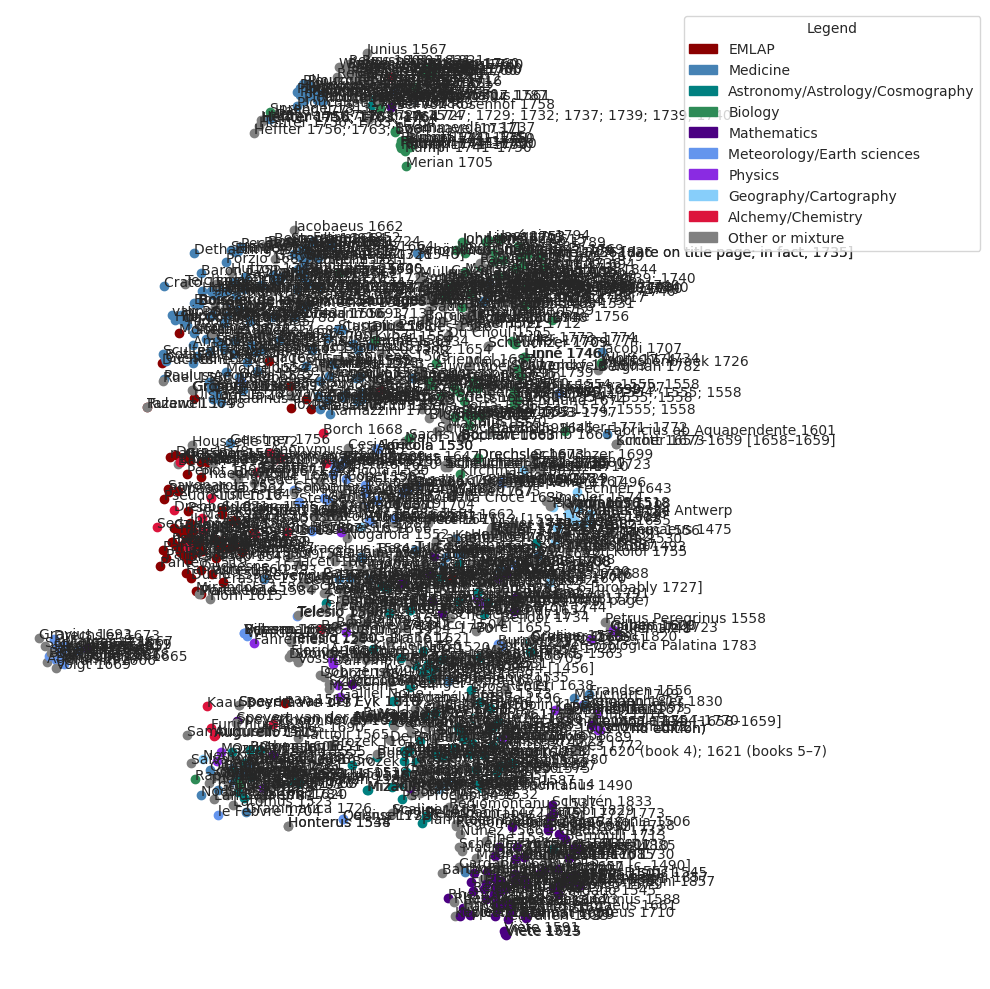

In [210]:
fig, ax = plt.subplots(figsize=(10, 10), tight_layout=True)

# Scatter plot with annotated labels
for n, (source, id) in enumerate(zip(combined_sources, combined_ids)):
    if source == "emlap":
        label = id_label_dict.get(id, None)
        color = "darkred"
    else:
        label = noscemus_id_label_dict.get(id, None)
        disc_list = noscemus_id_discipline_dict.get(id)
        if len(disc_list) == 1:
            color = disc_color_dict[disc_list[0]]
        else:
            color = "grey"
    ax.scatter(X_embedded[n, 0], X_embedded[n, 1], color=color)
    ax.annotate(label, (X_embedded[n, 0], X_embedded[n, 1]))

# Create legend handles from legend_dict
legend_handles = [
    mpatches.Patch(color=color, label=label) for label, color in legend_dict.items()
]
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Legend")
# Hide the axis
ax.axis('off')

In [211]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Run t-SNE
tsne = TSNE(n_components=3, metric='cosine')  # Use 'cosine' as the distance metric
X_embedded = tsne.fit_transform(X.toarray())  # Convert sparse matrix X to dense

In [215]:
scatter_data = [
    go.Scatter3d(
        x=[X_embedded[n, 0]],
        y=[X_embedded[n, 1]],
        z=[X_embedded[n, 2]],
        mode='markers+text',
        marker=dict(size=5, color=(
            "darkred" if source == "emlap" else (
                disc_color_dict[disc_list[0]] if len(
                    disc_list := noscemus_id_discipline_dict.get(id, [])) == 1 else "grey"
            ))),
        text=(id_label_dict if source == "emlap" else noscemus_id_label_dict).get(id, None),
        textposition='top center',
        hoverinfo="text",
        hovertext=f"Label: {(id_label_dict if source == 'emlap' else noscemus_id_label_dict).get(id, 'N/A')}<br>Discipline: {'EMLAP' if source == 'emlap' else (disc_list[0] if len(disc_list) == 1 else 'Other or mixture')}",
        showlegend=False  # Disable legend for individual points
    ) for n, (source, id) in enumerate(zip(combined_sources, combined_ids))
]

fig = go.Figure(data=scatter_data)
fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),  # Hide X-axis
        yaxis=dict(visible=False),  # Hide Y-axis
        zaxis=dict(visible=False)  # Hide Z-axis
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)
fig.show()


In [218]:
# Save the figure as an HTML file
pio.write_html(fig, file="../figures/tfidf_noscemus&emlap_3d.html", auto_open=False)

In [ ]:
pio.write_html(fig, file="/srv/webserver/data/www/plotly/tfidf_noscemus&emlap_3d.html", auto_open=False)